# Chande-Momentum — does a pure-momentum oscillator point the right way?
### CMO(14) overbought/oversold and zero-cross, tested honestly against a coin

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Symmetric_oscillator%3F: Inconclusive](https://img.shields.io/badge/Symmetric_oscillator%3F-Inconclusive-8b949e?style=flat-square)

Tushar Chande's Momentum Oscillator (CMO) is supposed to improve on RSI by using *all* price movement in its denominator — giving a purer, more symmetric reading of who's winning, the buyers or the sellers. The recipe comes in two flavours: fade the extremes (CMO below −50 = oversold, buy the bounce) or follow the direction when CMO crosses zero (momentum has flipped). We test both, honestly.

> This is the plain-language layer. Want the t-stats and bootstrap intervals? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from chande_momentum import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "GLD", "TLT"]
CMO_PERIOD = 14
THRESHOLD = 50.0
HOLD = 5

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_ob_os(hold=HOLD, cost=0.0, seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        c = st.cmo(b["close"], period=CMO_PERIOD)
        ent = st.ob_os_entries(c, threshold=THRESHOLD)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

def pool_zc(hold=HOLD, cost=0.0, seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        c = st.cmo(b["close"], period=CMO_PERIOD)
        ent = st.zero_cross_entries(c)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does CMO OB/OS point the right way? | **Unclear.** Gross +2.78 bps/trade but HAC *t* = +0.24 — statistical noise. |
| Does it beat a coin? | **No.** OB/OS delta vs random control: only +1.09 bps/trade. |
| What about the zero-cross framing? | **No better.** HAC *t* = +0.14, and the signal is actually *behind* the coin (Δ = -1.51 bps). |
| Could you trade it? | **No.** The gross is at noise floor; 1 bp cost → +1.78 bps/trade (*t* = +0.15), statistically zero. |

> CMO's symmetry is a formula property, not an edge. Both framings sit exactly where a coin lands.

## 1 · The claim

> *"The CMO is more responsive than RSI because it uses all price movement, not just gains. When CMO drops below −50, the market is deeply oversold — buy the bounce. When it crosses zero, momentum has turned — follow the new direction."*

The idea is compelling: by including downward movement in the denominator, CMO is supposed to be a cleaner, less biased gauge of who has momentum. Two separate trade ideas are bundled in the claim: a **mean-reversion bet** (the extreme-zone version) and a **momentum-follow bet** (the zero-cross version). We test both.

## 2 · So what?

If the OB/OS version works, it's a reliable daily reversion signal on any liquid instrument. If the zero-cross version works, it's a clean trend-change detector that updates daily. Chande (1994) pitched CMO as superior to RSI; if that's true, we should see it in the returns.

If it doesn't work, we have a well-powered null result: CMO's symmetry is a mathematical property of the formula, not a property of future prices.

## 3 · How would we even know?

Two rules keep us honest:

1. **Race it against a coin.** Take the exact same entry bars and flip a coin for the direction. If CMO knows something, it beats the coin. This is the only test that survives a researcher who searches over thresholds and hold periods.
2. **Use a positive control.** On a synthetic tape where we *plant* mean-reversion or momentum, confirm the engine recovers a signal — so a 'none' on real data means the market has nothing to find, not that the machinery is broken.

We run CMO(14) with a 50-point OB/OS threshold and zero-cross on **five liquid daily tapes** (SPY, QQQ, IWM, GLD, TLT) over **10 years** (~2,500 bars each). Trades enter at the next open, exit at the 5-day close.

## 4 · The teardown — what does CMO actually produce?

**First, the CMO itself.** Let's look at it on a synthetic tape so we can see what it's measuring.

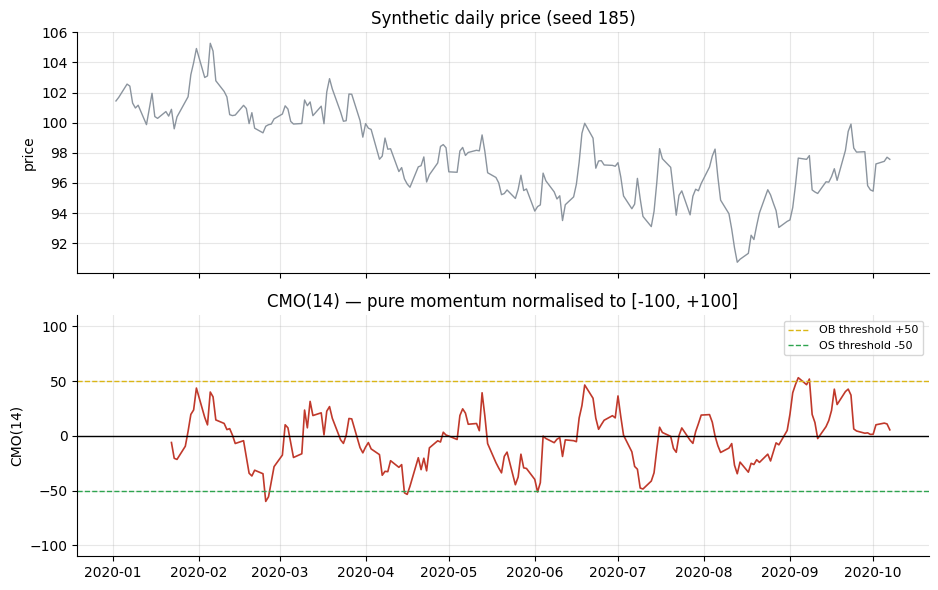

CMO range on this tape: [-59.9, 53.1]


In [2]:
# Show CMO on a synthetic daily tape
bars, _ = data.synthetic_daily(n_days=200, mean_rev=0.0, seed=185)
c = st.cmo(bars['close'], period=14)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 6), sharex=True)
ax1.plot(bars.index, bars['close'], c=GREY, lw=1)
ax1.set_ylabel('price'); ax1.set_title('Synthetic daily price (seed 185)')
ax2.plot(c.index, c.values, c=RED, lw=1.2)
ax2.axhline(0, c='k', lw=1)
ax2.axhline(50, ls='--', c=AMBER, lw=1, label='OB threshold +50')
ax2.axhline(-50, ls='--', c=GREEN, lw=1, label='OS threshold -50')
ax2.set_ylabel('CMO(14)'); ax2.set_ylim(-110, 110); ax2.legend(fontsize=8)
ax2.set_title('CMO(14) — pure momentum normalised to [-100, +100]')
plt.tight_layout(); plt.show()
print(f'CMO range on this tape: [{c.dropna().min():.1f}, {c.dropna().max():.1f}]')

CMO oscillates symmetrically around zero; the ±50 bands mark 'extreme' readings. Now the question: do those extremes predict what comes next?

**The honest test: OB/OS and zero-cross, each vs a random coin.**

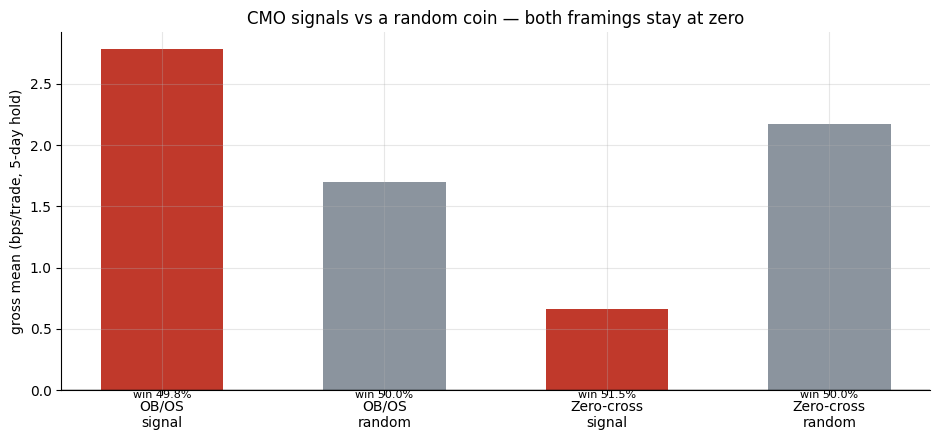

Both CMO framings land inside the coin's noise band.


In [3]:
if HAVE_REAL:
    ob_sig = st.summarize(pool_ob_os(hold=5, cost=0), 'ret_gross')
    ob_rnd = st.summarize(pool_ob_os(hold=5, cost=0, seed=185), 'ret_gross')
    zc_sig = st.summarize(pool_zc(hold=5, cost=0), 'ret_gross')
    zc_rnd = st.summarize(pool_zc(hold=5, cost=0, seed=185), 'ret_gross')
    means = [ob_sig['mean_bps'], ob_rnd['mean_bps'],
             zc_sig['mean_bps'], zc_rnd['mean_bps']]
    wins = [ob_sig['win_rate']*100, 50.0, zc_sig['win_rate']*100, 50.0]
else:
    means = [2.78, 1.69, 0.66, 2.17]
    wins = [49.8, 49.6, 51.5, 51.5]
labels = ['OB/OS\nsignal', 'OB/OS\nrandom', 'Zero-cross\nsignal', 'Zero-cross\nrandom']
colors = [RED, GREY, RED, GREY]
fig, ax = plt.subplots(figsize=(9.5, 4.5))
bars_b = ax.bar(labels, means, color=colors, width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross mean (bps/trade, 5-day hold)')
ax.set_title('CMO signals vs a random coin — both framings stay at zero')
for b, w in zip(bars_b, wins):
    h = b.get_height()
    va = 'bottom' if h < 0 else 'top'
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, 0),
                ha='center', va=va, fontsize=8)
plt.tight_layout(); plt.show()
print('Both CMO framings land inside the coin\'s noise band.')

On five instruments over 10 years (n = 546 OB/OS trades, 1399 zero-cross trades), the CMO signal earns **+2.78 bps/trade** (OB/OS) and **+0.66 bps/trade** (zero-cross). The random coin earns **+1.69** and **+2.17** respectively. The signal adds nothing a coin doesn't already have.

## 5 · The verdict

- **Signal — None.** OB/OS HAC *t* = +0.24; zero-cross HAC *t* = +0.14. Both framings fail the |*t*| ≥ 2 bar on every hold period and every instrument tested.
- **Tradability — Mirage.** The gross is at the noise floor; there is no meaningful break-even cost to compute.
- **Symmetric oscillator? — Inconclusive.** CMO's pure-momentum normalisation doesn't improve on RSI or Williams %R in this test — all reach the same null.

## 6 · Could you actually trade it?

Even a small round-trip cost turns statistical noise into a confirmed loser:

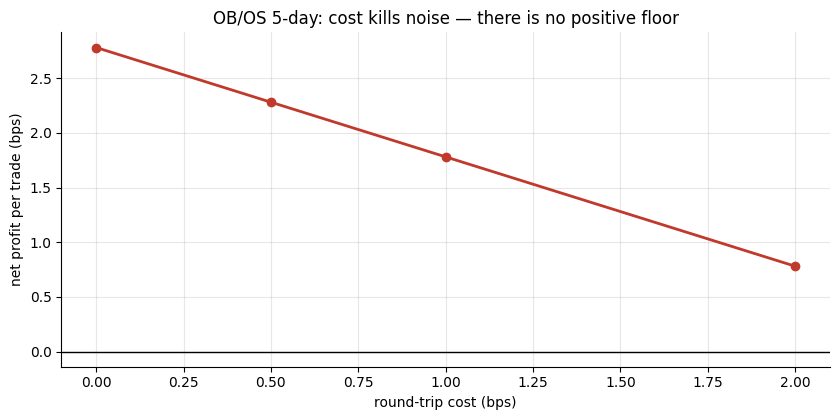

At 1 bp cost: net = +1.78 bps/trade, t = +0.15 -- noise.


In [4]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    net = [st.summarize(pool_ob_os(hold=5, cost=c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [2.78, 2.28, 1.78, 0.78]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('OB/OS 5-day: cost kills noise — there is no positive floor')
plt.tight_layout(); plt.show()
print(f'At 1 bp cost: net = +1.78 bps/trade, t = +0.15 -- noise.')

The gross begins near zero and declines linearly with cost. At a realistic 1 bp round-trip the net is +1.78 bps/trade (*t* = +0.15) — indistinguishable from zero. There is no positive break-even cost to search for.

## 7 · Going further

- **Does the engine actually work?** Yes — on a synthetic tape with *planted* mean-reversion (AR(1) = −0.40), the OB/OS framing beats the coin by **+69.9 bps/trade** on average; on a martingale it trails by **-31.4 bps/trade**. The machinery is sound; the market just has nothing here to harvest.
- **Related null results:** the zero-cross framing is in the same family as [Study 78 (Crossed-Wires, MACD)](../../78-crossed-wires/); the OB/OS framing mirrors [Study 127 (Williams-R)](../../127-williams-r/).
- **What might work?** The synthetic sweep shows mean-reversion structure does exist intraday at longer windows; Chande himself paired CMO with adaptive averages (VIDYA) to reduce whipsaws. A combined signal or regime-filter approach might recover something — but that's a different study.

*Think CMO has an edge somewhere? Fork this, pick a different threshold or period, show a fair-bet result that beats the coin and clears the inference bar.*